# FeatureTracker Test: Persistent Lake IDs (2018 → 2019)

Tests the `FeatureTracker` on real Greenland supraglacial lake data.
Matches lakes detected in 2018 to those detected in 2019 by centroid proximity,
per IMBIE drainage basin.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

from sat_tile_stack.ids import FeatureTracker

## Load data

In [2]:
df_2018 = pd.read_csv("../data/labels_2018_volumes.csv")
df_2019 = pd.read_csv("../data/labels_2019_volumes.csv")

gdf_2018 = gpd.GeoDataFrame(
    df_2018,
    geometry=df_2018["geometry"].apply(wkt.loads),
    crs="EPSG:4326",
)
gdf_2019 = gpd.GeoDataFrame(
    df_2019,
    geometry=df_2019["geometry"].apply(wkt.loads),
    crs="EPSG:4326",
)

print(f"2018: {len(gdf_2018)} lakes across regions {sorted(gdf_2018['region'].unique())}")
print(f"2019: {len(gdf_2019)} lakes across regions {sorted(gdf_2019['region'].unique())}")

2018: 3846 lakes across regions ['CW', 'NE', 'NO', 'NW', 'SE', 'SW']
2019: 6146 lakes across regions ['CW', 'NE', 'NO', 'NW', 'SE', 'SW']


## Visualize all lakes (both years)

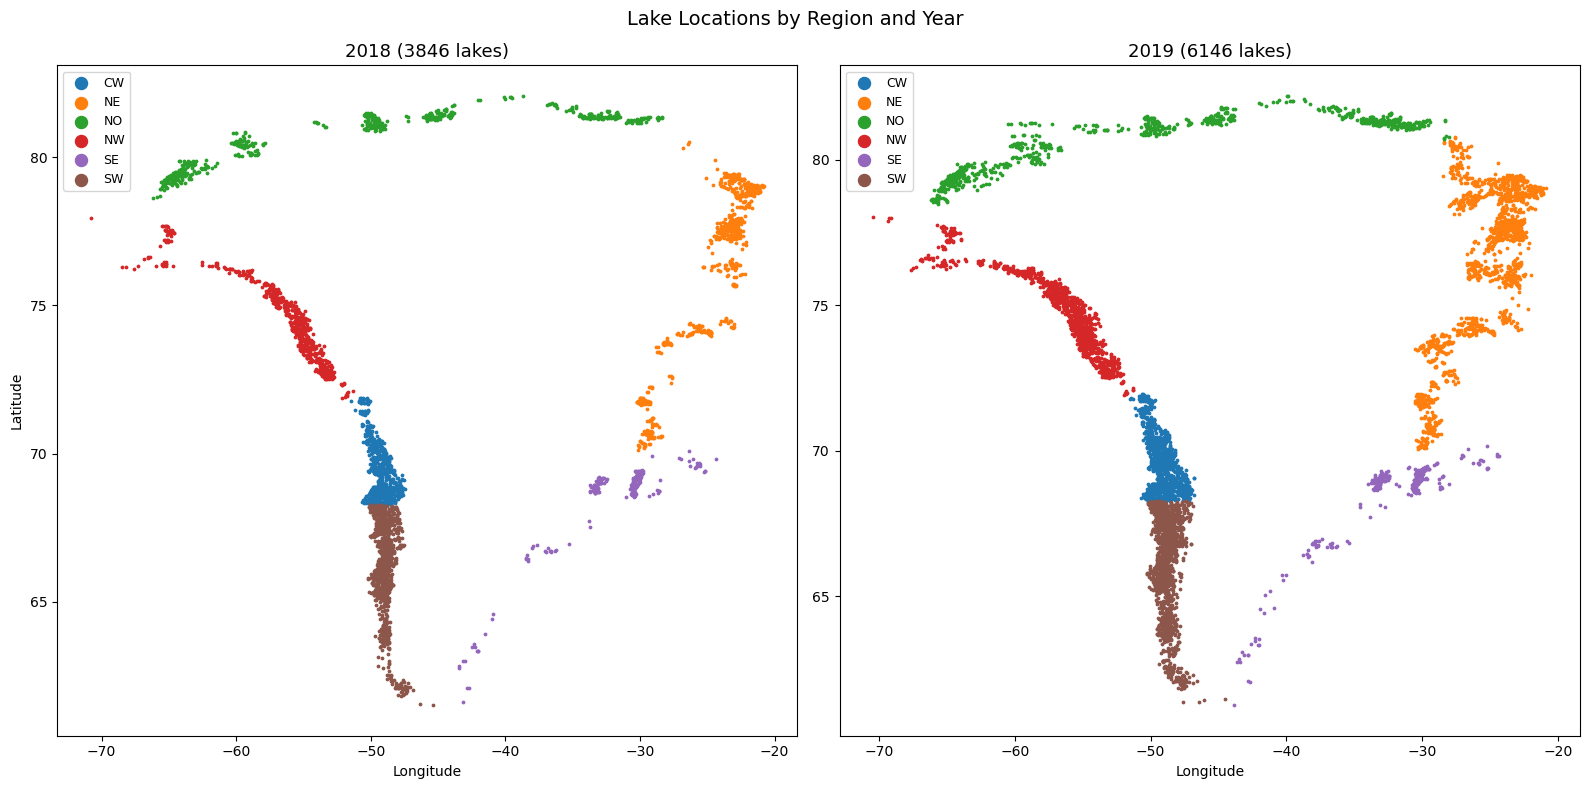

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 2018
for region, color in zip(sorted(gdf_2018['region'].unique()),
                         plt.cm.tab10.colors):
    subset = gdf_2018[gdf_2018['region'] == region]
    axes[0].scatter(subset['lon'], subset['lat'], s=3, label=region, color=color)
axes[0].set_title(f"2018 ({len(gdf_2018)} lakes)", fontsize=13)
axes[0].legend(markerscale=5, fontsize=9)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

# 2019
for region, color in zip(sorted(gdf_2019['region'].unique()),
                         plt.cm.tab10.colors):
    subset = gdf_2019[gdf_2019['region'] == region]
    axes[1].scatter(subset['lon'], subset['lat'], s=3, label=region, color=color)
axes[1].set_title(f"2019 ({len(gdf_2019)} lakes)", fontsize=13)
axes[1].legend(markerscale=5, fontsize=9)
axes[1].set_xlabel("Longitude")

fig.suptitle("Lake Locations by Region and Year", fontsize=14)
plt.tight_layout()
plt.show()

## Run FeatureTracker per basin

Tolerance is now in **meters** — the tracker internally reprojects to a suitable projected CRS
(polar stereographic for Greenland) before computing centroid distances.

In [4]:
TOLERANCE_M = 500  # meters

regions = sorted(set(gdf_2018["region"].unique()) | set(gdf_2019["region"].unique()))

# Store results per region
results = {}
trackers = {}

for region in regions:
    g18 = gdf_2018[gdf_2018["region"] == region].copy().reset_index(drop=True)
    g19 = gdf_2019[gdf_2019["region"] == region].copy().reset_index(drop=True)

    tracker = FeatureTracker(method="centroid", tolerance_m=TOLERANCE_M, id_prefix=region)
    assignments_2018 = tracker.register(g18, "2018")
    assignments_2019 = tracker.register(g19, "2019")

    status = tracker.get_status("2019")
    results[region] = {
        "n_2018": len(g18),
        "n_2019": len(g19),
        "matched": len(status["persistent"]),
        "new": len(status["new"]),
        "missing": len(status["missing"]),
        "status": status,
        "assignments_2019": assignments_2019,
        "gdf_2018": g18,
        "gdf_2019": g19,
    }
    trackers[region] = tracker

# Print summary table
print(f"{'Region':<8} {'2018':>6} {'2019':>6} {'Matched':>8} {'New':>6} {'Missing':>8} {'Match%':>7}")
print("-" * 52)
for region in regions:
    r = results[region]
    pct = r['matched'] / r['n_2019'] * 100 if r['n_2019'] > 0 else 0
    print(f"{region:<8} {r['n_2018']:>6} {r['n_2019']:>6} {r['matched']:>8} {r['new']:>6} {r['missing']:>8} {pct:>6.1f}%")

# Totals
tot = {k: sum(r[k] for r in results.values()) for k in ['n_2018', 'n_2019', 'matched', 'new', 'missing']}
pct = tot['matched'] / tot['n_2019'] * 100
print("-" * 52)
print(f"{'TOTAL':<8} {tot['n_2018']:>6} {tot['n_2019']:>6} {tot['matched']:>8} {tot['new']:>6} {tot['missing']:>8} {pct:>6.1f}%")

    _match_centroid: 538 matches from 539 candidates (tolerance=500m, max_match_dist=491.5m)
    _match_centroid: 468 matches from 472 candidates (tolerance=500m, max_match_dist=473.7m)
    _match_centroid: 380 matches from 384 candidates (tolerance=500m, max_match_dist=492.4m)
    _match_centroid: 498 matches from 500 candidates (tolerance=500m, max_match_dist=496.5m)
    _match_centroid: 141 matches from 143 candidates (tolerance=500m, max_match_dist=473.3m)
    _match_centroid: 743 matches from 747 candidates (tolerance=500m, max_match_dist=499.2m)
Region     2018   2019  Matched    New  Missing  Match%
----------------------------------------------------
CW          679   1000      538    462      141   53.8%
NE          705   1540      468   1072      237   30.4%
NO          539    754      380    374      159   50.4%
NW          633   1037      498    539      135   48.0%
SE          213    291      141    150       72   48.5%
SW         1077   1524      743    781      334   48.

## Visualize matching results per region

For each region, shows:
- **Blue**: lakes matched between 2018 and 2019 (persistent)
- **Green**: new lakes in 2019 (not in 2018)
- **Red**: lakes from 2018 that are missing in 2019

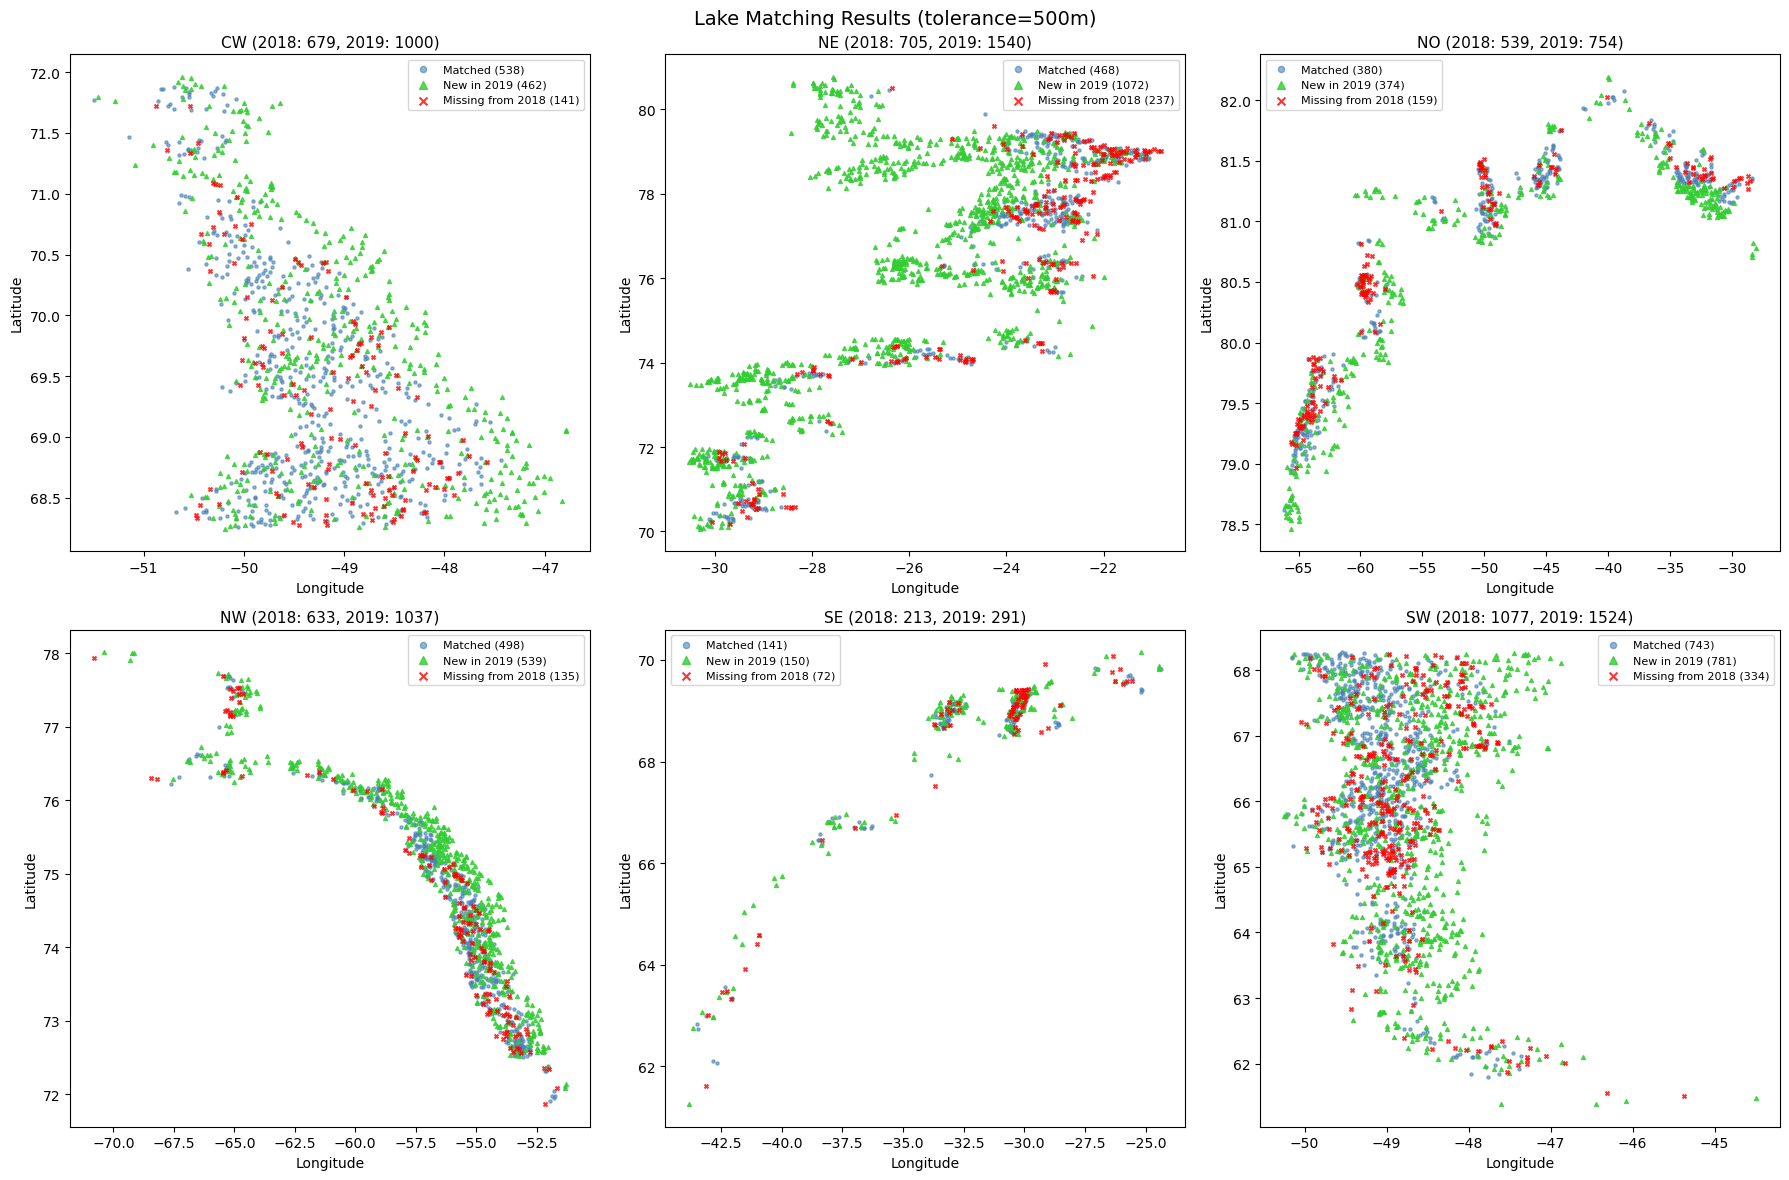

In [5]:
n_regions = len(regions)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, region in enumerate(regions):
    ax = axes[i]
    r = results[region]
    g18 = r["gdf_2018"]
    g19 = r["gdf_2019"]
    status = r["status"]
    assignments = r["assignments_2019"]

    # Classify 2019 lakes
    persistent_pids = set(status["persistent"])
    matched_idx = [idx for idx, pid in assignments.items() if pid in persistent_pids]
    new_idx = [idx for idx, pid in assignments.items() if pid not in persistent_pids]

    # Missing from 2018: find which 2018 lakes have IDs not in 2019
    pids_in_2019 = set(assignments.values())
    tracker = trackers[region]
    missing_2018_idx = []
    for (tl, si), pid in tracker.get_id_table().items():
        if tl == "2018" and pid in set(status["missing"]):
            missing_2018_idx.append(si)

    # Plot matched 2019 lakes (blue)
    if matched_idx:
        matched = g19.loc[matched_idx]
        ax.scatter(matched.geometry.centroid.x, matched.geometry.centroid.y,
                   s=5, c="steelblue", alpha=0.6, label=f"Matched ({len(matched_idx)})")

    # Plot new 2019 lakes (green)
    if new_idx:
        new = g19.loc[new_idx]
        ax.scatter(new.geometry.centroid.x, new.geometry.centroid.y,
                   s=8, c="limegreen", marker="^", alpha=0.8, label=f"New in 2019 ({len(new_idx)})")

    # Plot missing 2018 lakes (red)
    if missing_2018_idx:
        missing = g18.loc[missing_2018_idx]
        ax.scatter(missing.geometry.centroid.x, missing.geometry.centroid.y,
                   s=8, c="red", marker="x", alpha=0.8, label=f"Missing from 2018 ({len(missing_2018_idx)})")

    ax.set_title(f"{region} (2018: {r['n_2018']}, 2019: {r['n_2019']})", fontsize=11)
    ax.legend(fontsize=8, markerscale=2)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

# Hide extra axes if fewer than 6 regions
for j in range(len(regions), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Lake Matching Results (tolerance={TOLERANCE_M}m)", fontsize=14)
plt.tight_layout()
plt.show()

## Zoom into one region: CW

Detailed view of the CW (central-west) basin with matched pairs connected by lines.

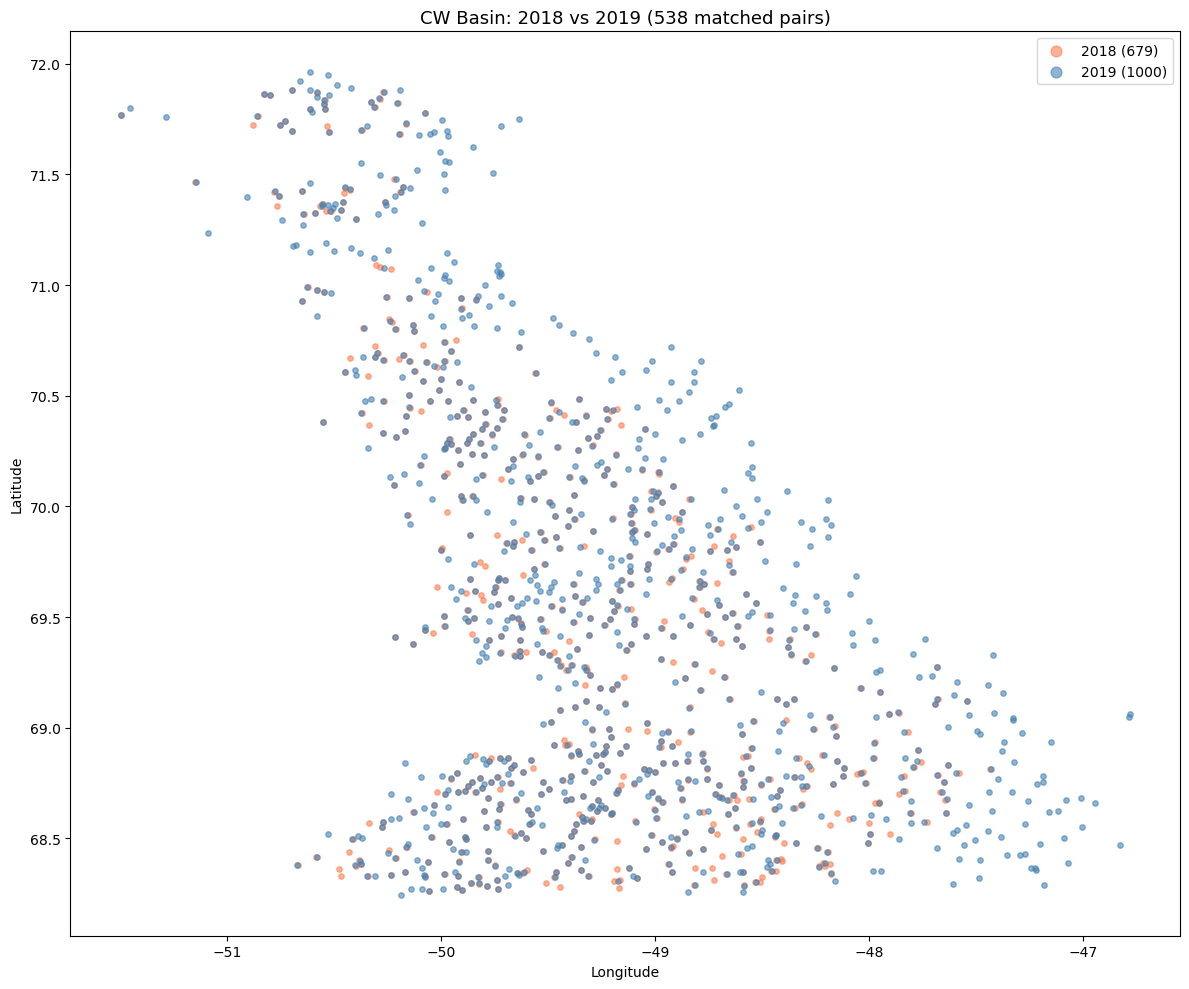

FeatureTracker (method=centroid, tolerance=500)
  Registered 2 time periods: 2018 (679 features), 2019 (1000 features)
  Total persistent features: 1141
  2019: 538 matched, 462 new, 141 missing
  Features in ALL periods: 538


In [6]:
region = "CW"
r = results[region]
g18 = r["gdf_2018"]
g19 = r["gdf_2019"]
tracker = trackers[region]
status = r["status"]
assignments = r["assignments_2019"]

fig, ax = plt.subplots(figsize=(12, 10))

# Draw lines connecting matched pairs
persistent_pids = set(status["persistent"])
n_lines = 0
for idx_19, pid in assignments.items():
    if pid in persistent_pids:
        # Find the 2018 entry for this persistent ID
        for (tl, si), p in tracker.get_id_table().items():
            if tl == "2018" and p == pid:
                c18 = g18.loc[si].geometry.centroid
                c19 = g19.loc[idx_19].geometry.centroid
                ax.plot([c18.x, c19.x], [c18.y, c19.y],
                        color="gray", linewidth=0.3, alpha=0.4)
                n_lines += 1
                break

# Plot 2018 lakes
ax.scatter(g18.geometry.centroid.x, g18.geometry.centroid.y,
           s=15, c="coral", alpha=0.6, label=f"2018 ({len(g18)})")

# Plot 2019 lakes
ax.scatter(g19.geometry.centroid.x, g19.geometry.centroid.y,
           s=15, c="steelblue", alpha=0.6, label=f"2019 ({len(g19)})")

ax.set_title(f"{region} Basin: 2018 vs 2019 ({n_lines} matched pairs)", fontsize=13)
ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

# Print tracker summary for CW
tracker.summary()

In [9]:
# Show 10 example persistent IDs per region
print("Example Persistent IDs (lakes matched between 2018 and 2019)\n")
print(f"{'ID':<14} {'2018 centroid (lon, lat)':<30} {'2019 centroid (lon, lat)':<30} {'Shift (m)'}")
print("-" * 85)

for region in regions:
    tracker = trackers[region]
    table = tracker.get_id_table()
    g18 = results[region]["gdf_2018"]
    g19 = results[region]["gdf_2019"]

    # Find lakes present in both years
    pid_entries = {}
    for (tl, si), pid in table.items():
        pid_entries.setdefault(pid, {})[tl] = si

    both = {pid: e for pid, e in pid_entries.items() if "2018" in e and "2019" in e}

    # Project for distance calculation
    proj_crs = best_crs_for_point(g18.geometry.centroid.x.mean(), g18.geometry.centroid.y.mean())
    g18_proj = g18.to_crs(proj_crs)
    g19_proj = g19.to_crs(proj_crs)

    count = 0
    for pid, entries in sorted(both.items()):
        if count >= 10:
            break
        si_18 = entries["2018"]
        si_19 = entries["2019"]
        c18 = g18.loc[si_18].geometry.centroid
        c19 = g19.loc[si_19].geometry.centroid
        c18_p = g18_proj.loc[si_18].geometry.centroid
        c19_p = g19_proj.loc[si_19].geometry.centroid
        dist = np.sqrt((c18_p.x - c19_p.x)**2 + (c18_p.y - c19_p.y)**2)
        print(f"{pid:<14} ({c18.x:>9.4f}, {c18.y:>8.4f})      ({c19.x:>9.4f}, {c19.y:>8.4f})      {dist:>6.1f}")
        count += 1
    print()

Example Persistent IDs (lakes matched between 2018 and 2019)

ID             2018 centroid (lon, lat)       2019 centroid (lon, lat)       Shift (m)
-------------------------------------------------------------------------------------
CW_0001        ( -50.1735,  70.6837)      ( -50.1802,  70.6818)       318.5
CW_0002        ( -49.7564,  69.6148)      ( -49.7540,  69.6131)       203.8
CW_0006        ( -49.0349,  69.7379)      ( -49.0351,  69.7381)        22.4
CW_0007        ( -48.5280,  69.5653)      ( -48.5280,  69.5654)        16.6
CW_0008        ( -47.9806,  68.8642)      ( -47.9832,  68.8647)       115.8
CW_0009        ( -48.4167,  68.7172)      ( -48.4165,  68.7195)       250.4
CW_0010        ( -49.3110,  69.4195)      ( -49.3107,  69.4196)        15.3
CW_0011        ( -51.4988,  71.7686)      ( -51.4961,  71.7686)        91.7
CW_0012        ( -48.8768,  68.6755)      ( -48.8765,  68.6756)        15.6
CW_0013        ( -48.6163,  69.4611)      ( -48.6177,  69.4613)        63.2

NE_0

## Experiment with tolerance

How does the match rate change with different tolerances?

    _match_centroid: 316 matches from 316 candidates (tolerance=100m, max_match_dist=99.9m)
tol=  100m | matched= 316, new= 684, missing= 363 | match rate: 31.6%
    _match_centroid: 439 matches from 439 candidates (tolerance=200m, max_match_dist=198.8m)
tol=  200m | matched= 439, new= 561, missing= 240 | match rate: 43.9%
    _match_centroid: 494 matches from 494 candidates (tolerance=300m, max_match_dist=298.9m)
tol=  300m | matched= 494, new= 506, missing= 185 | match rate: 49.4%
    _match_centroid: 538 matches from 539 candidates (tolerance=500m, max_match_dist=491.5m)
tol=  500m | matched= 538, new= 462, missing= 141 | match rate: 53.8%
    _match_centroid: 557 matches from 562 candidates (tolerance=750m, max_match_dist=728.8m)
tol=  750m | matched= 557, new= 443, missing= 122 | match rate: 55.7%
    _match_centroid: 566 matches from 576 candidates (tolerance=1000m, max_match_dist=982.9m)
tol= 1000m | matched= 566, new= 434, missing= 113 | match rate: 56.6%
    _match_centroid: 5

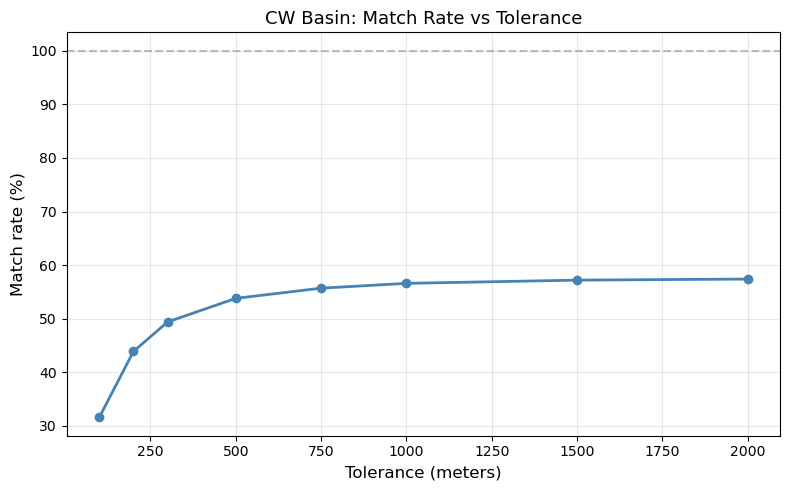

In [7]:
# Test CW region with different tolerances (in meters)
g18 = gdf_2018[gdf_2018["region"] == "CW"].copy().reset_index(drop=True)
g19 = gdf_2019[gdf_2019["region"] == "CW"].copy().reset_index(drop=True)

tolerances_m = [100, 200, 300, 500, 750, 1000, 1500, 2000]
match_rates = []

for tol in tolerances_m:
    tracker = FeatureTracker(method="centroid", tolerance_m=tol, id_prefix="CW")
    tracker.register(g18, "2018")
    tracker.register(g19, "2019")
    status = tracker.get_status("2019")
    rate = len(status["persistent"]) / len(g19) * 100
    match_rates.append(rate)
    print(f"tol={tol:>5}m | matched={len(status['persistent']):>4}, "
          f"new={len(status['new']):>4}, missing={len(status['missing']):>4} "
          f"| match rate: {rate:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tolerances_m, match_rates, "o-", color="steelblue", linewidth=2)
ax.set_xlabel("Tolerance (meters)", fontsize=12)
ax.set_ylabel("Match rate (%)", fontsize=12)
ax.set_title("CW Basin: Match Rate vs Tolerance", fontsize=13)
ax.grid(True, alpha=0.3)
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Nearest-neighbor distances (2019 lakes to closest 2018 lake):
  Min:    2.1 m
  Max:    39046.0 m
  Median: 317.3 m
  Mean:   3238.7 m

  Within    50m:  169 lakes (16.9%)
  Within   100m:  316 lakes (31.6%)
  Within   200m:  439 lakes (43.9%)
  Within   500m:  539 lakes (53.9%)
  Within  1000m:  576 lakes (57.6%)
  Within  2000m:  638 lakes (63.8%)
  Within  5000m:  800 lakes (80.0%)


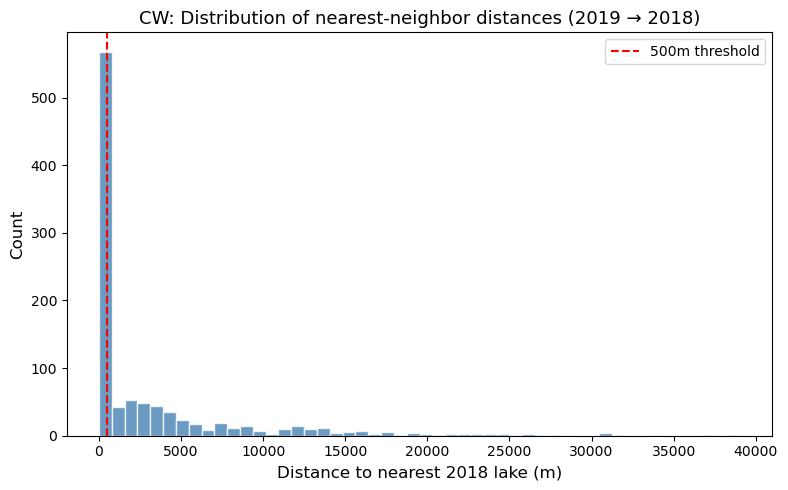

In [8]:
# Check actual centroid distances for CW matches
from sat_tile_stack.ids import _match_centroid
from sat_tile_stack.bounds import best_crs_for_point
from scipy.spatial import cKDTree

g18 = gdf_2018[gdf_2018["region"] == "CW"].copy().reset_index(drop=True)
g19 = gdf_2019[gdf_2019["region"] == "CW"].copy().reset_index(drop=True)

# Project to meters (same as what FeatureTracker does internally)
proj_crs = best_crs_for_point(g18.geometry.centroid.x.mean(), g18.geometry.centroid.y.mean())
g18_proj = g18.to_crs(proj_crs)
g19_proj = g19.to_crs(proj_crs)

# Compute nearest-neighbor distances
centroids_18 = np.array([(g.centroid.x, g.centroid.y) for g in g18_proj.geometry])
centroids_19 = np.array([(g.centroid.x, g.centroid.y) for g in g19_proj.geometry])

tree = cKDTree(centroids_18)
distances, indices = tree.query(centroids_19, k=1)

print(f"Nearest-neighbor distances (2019 lakes to closest 2018 lake):")
print(f"  Min:    {distances.min():.1f} m")
print(f"  Max:    {distances.max():.1f} m")
print(f"  Median: {np.median(distances):.1f} m")
print(f"  Mean:   {distances.mean():.1f} m")
print()

# Distribution
thresholds = [50, 100, 200, 500, 1000, 2000, 5000]
for t in thresholds:
    n = (distances <= t).sum()
    print(f"  Within {t:>5}m: {n:>4} lakes ({n/len(distances)*100:.1f}%)")

# Histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(distances, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Distance to nearest 2018 lake (m)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("CW: Distribution of nearest-neighbor distances (2019 → 2018)", fontsize=13)
ax.axvline(x=500, color="red", linestyle="--", label="500m threshold")
ax.legend()
plt.tight_layout()
plt.show()